# IA708 — Fairness, Interprétabilité & Robustesse
## Dataset : UCI German Credit

Ce notebook suit les quatre tâches demandées par le sujet :

| Tâche | Contenu |
|---|---|
| **1** | Modèle de référence (baseline) — classification |
| **2** | Méthodes d'équité — reweighing + calibration par groupe |
| **3** | Interprétabilité — SHAP linéaire exact + importance par permutation |
| **4** | Robustesse — perturbation contrôlée, analyse des dégradations |

Toutes les étapes appellent directement les fonctions du module `german_credit_rai.pipeline`.

In [2]:
%matplotlib inline
# ── Imports ───────────────────────────────────────────────────────────────────
import logging
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from german_credit_rai.pipeline import (
    # Data
    RunConfig, load_german_credit, prepare_dataset, stratified_split,
    GERMAN_COLUMNS, NUMERIC_COLUMNS, GENDER_MAP,
    # Preprocessing
    TabularPreprocessor,
    # Models
    LogisticRegressionGD,
    # Fairness
    compute_reweighing_weights, select_threshold,
    compute_group_thresholds, evaluate_with_group_thresholds,
    # Evaluation
    evaluate_prediction_set, compute_performance_metrics,
    compute_fairness_metrics, confusion_counts,
    roc_auc_score_binary, compute_roc_curve,
    # Interpretability
    compute_linear_shap, aggregate_shap_by_raw_feature, permutation_importance,
    # Robustness
    perturb_features,
    # Utils
    write_summary,
)

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(levelname)-8s | %(message)s',
                    datefmt='%H:%M:%S')
logger = logging.getLogger('notebook')

# ── Paramètres reproductibles ─────────────────────────────────────────────────
DATA_PATH   = Path('data/raw/german.data')
OUTPUT_DIR  = Path('outputs/notebook_run')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED        = 42
TRAIN_RATIO = 0.6
VAL_RATIO   = 0.2
TEST_RATIO  = 0.2
SENSITIVE   = 'gender'     # 'gender' ou 'age'
AGE_THRESH  = 25
LR          = 0.03
EPOCHS      = 3500
L2          = 0.01
NOISE_SCALE = 0.2
SWAP_PROB   = 0.1
PERM_REPS   = 10
PP_CRIT     = 'demographic_parity'

COLORS = {'baseline': '#2f6f9f', 'fair_reweighing': '#d97c3a', 'fair_postprocessing': '#3aaa7c'}
print('Configuration OK — seed=%d, sensitive=%s' % (SEED, SENSITIVE))

Configuration OK — seed=42, sensitive=gender


---
## 0. Chargement & exploration du dataset

In [3]:
raw = load_german_credit(DATA_PATH, download_if_missing=True)
print(f'Dimensions : {raw.shape}   |   Taux de défaut : {raw["default"].mean():.1%}')
raw.head(3)

Dimensions : (1000, 22)   |   Taux de défaut : 30.0%


,checking_status,duration_in_month,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate,personal_status_sex,other_debtors_guarantors,...,age_in_years,other_installment_plans,housing,number_of_existing_credits,job,number_of_people_liable,telephone,foreign_worker,raw_target,default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,67,A143,A152,2,A173,1,A192,A201,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,22,A143,A152,1,A173,1,A191,A201,2,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,49,A143,A152,1,A172,2,A191,A201,1,0


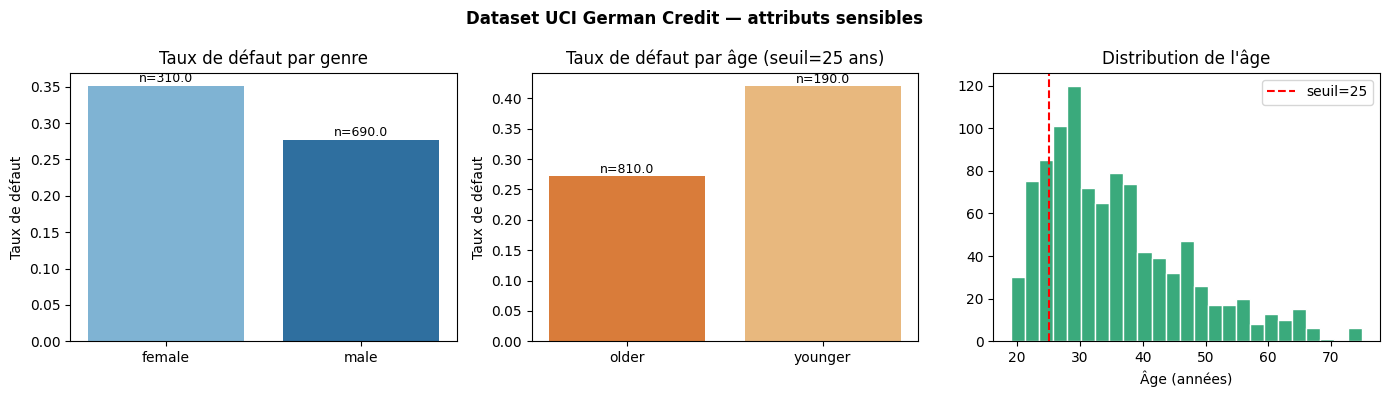

Biais initial : les groupes ont des taux de défaut différents. Un modèle naïf peut amplifier ces disparités.


In [4]:
# Distribution par attribut sensible
raw_view = raw.copy()
raw_view['gender'] = raw_view['personal_status_sex'].map(GENDER_MAP)
raw_view['age_group'] = np.where(raw_view['age_in_years'] > AGE_THRESH, 'older', 'younger')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Taux de défaut par genre
grp_g = raw_view.groupby('gender')['default'].agg(['mean', 'count'])
axes[0].bar(grp_g.index, grp_g['mean'], color=['#7fb3d3', '#2f6f9f'])
axes[0].set_title('Taux de défaut par genre')
axes[0].set_ylabel('Taux de défaut')
for bar, (idx, row) in zip(axes[0].patches, grp_g.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'n={row["count"]}', ha='center', fontsize=9)

# Taux de défaut par âge
grp_a = raw_view.groupby('age_group')['default'].agg(['mean', 'count'])
axes[1].bar(grp_a.index, grp_a['mean'], color=['#d97c3a', '#e8b87e'])
axes[1].set_title(f'Taux de défaut par âge (seuil={AGE_THRESH} ans)')
axes[1].set_ylabel('Taux de défaut')
for bar, (idx, row) in zip(axes[1].patches, grp_a.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'n={row["count"]}', ha='center', fontsize=9)

# Distribution de l'âge
axes[2].hist(raw['age_in_years'], bins=25, color='#3aaa7c', edgecolor='white')
axes[2].axvline(AGE_THRESH, color='red', linestyle='--', label=f'seuil={AGE_THRESH}')
axes[2].set_title('Distribution de l\'âge')
axes[2].set_xlabel('Âge (années)')
axes[2].legend()

fig.suptitle('Dataset UCI German Credit — attributs sensibles', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()
print('Biais initial : les groupes ont des taux de défaut différents.',
      'Un modèle naïf peut amplifier ces disparités.')

In [4]:
# Préparation du dataset et split stratifié
dataset = prepare_dataset(raw, SENSITIVE, AGE_THRESH)

rng = np.random.default_rng(SEED)
train_idx, val_idx, test_idx = stratified_split(
    y=dataset.target, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO, rng=rng
)

X_train_raw = dataset.features.iloc[train_idx].reset_index(drop=True)
X_val_raw   = dataset.features.iloc[val_idx].reset_index(drop=True)
X_test_raw  = dataset.features.iloc[test_idx].reset_index(drop=True)
y_train, y_val, y_test = dataset.target[train_idx], dataset.target[val_idx], dataset.target[test_idx]
s_train, s_val, s_test = dataset.sensitive[train_idx], dataset.sensitive[val_idx], dataset.sensitive[test_idx]

preprocessor = TabularPreprocessor(numeric_columns=dataset.numeric_columns)
X_train = preprocessor.fit_transform(X_train_raw)
X_val   = preprocessor.transform(X_val_raw)
X_test  = preprocessor.transform(X_test_raw)

print(f'Split — train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}')
print(f'Taux de défaut — train={y_train.mean():.2%}  val={y_val.mean():.2%}  test={y_test.mean():.2%}')
print(f'Groupes sensibles : {sorted(np.unique(dataset.sensitive).tolist())}')
print(f'Features du modèle : {X_train.shape[1]} colonnes après encodage')

Split — train=600  val=200  test=200
Taux de défaut — train=30.00%  val=30.00%  test=30.00%
Groupes sensibles : ['female', 'male']
Features du modèle : 57 colonnes après encodage


---
## Tâche 1 — Modèle de référence (Baseline)

**Modèle** : régression logistique entraînée avec Adam (gradient descent), L2, early-stopping sur la validation.

Entraînement terminé à l'époque 370 (early-stopping patience=300)


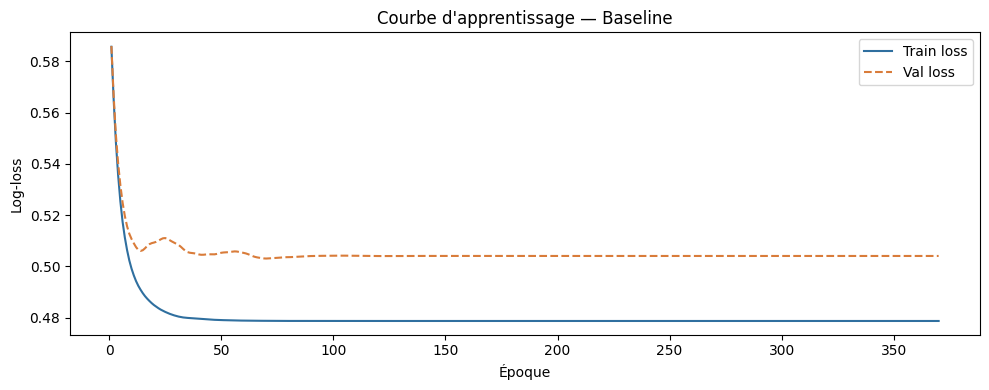

In [5]:
baseline_model = LogisticRegressionGD(
    learning_rate=LR, epochs=EPOCHS, l2=L2
).fit(X_train, y_train, X_val=X_val, y_val=y_val)

# Courbe d'apprentissage
history = pd.DataFrame(baseline_model.training_history_)
stopped_at = len(history)
print(f'Entraînement terminé à l\'époque {stopped_at} (early-stopping patience=300)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['epoch'], history['train_loss'], label='Train loss', color='#2f6f9f')
ax.plot(history['epoch'], history['monitor'], label='Val loss', color='#d97c3a', linestyle='--')
ax.set_xlabel('Époque')
ax.set_ylabel('Log-loss')
ax.set_title('Courbe d\'apprentissage — Baseline')
ax.legend()
fig.tight_layout()
plt.show()

In [6]:
# Sélection du seuil optimal sur la validation
baseline_threshold = select_threshold(y_val, baseline_model.predict_proba(X_val))
print(f'Seuil optimal (balanced accuracy) sur val : {baseline_threshold:.3f}')

# Évaluation sur le test
scores_b = baseline_model.predict_proba(X_test)
eval_b = evaluate_prediction_set(
    y_true=y_test, scores=scores_b, threshold=baseline_threshold,
    sensitive=s_test, privileged_group=dataset.privileged_group
)

perf = eval_b['performance']
print('\n=== Performance Baseline (test) ===')
for k, v in perf.items():
    print(f'  {k:<30s} {v:.4f}')

Seuil optimal (balanced accuracy) sur val : 0.290

=== Performance Baseline (test) ===
  accuracy                       0.7100
  precision                      0.5122
  recall                         0.7000
  specificity                    0.7143
  f1                             0.5915
  balanced_accuracy              0.7071
  roc_auc                        0.7900
  log_loss                       0.4909
  positive_prediction_rate       0.4100
  default_rate                   0.3000


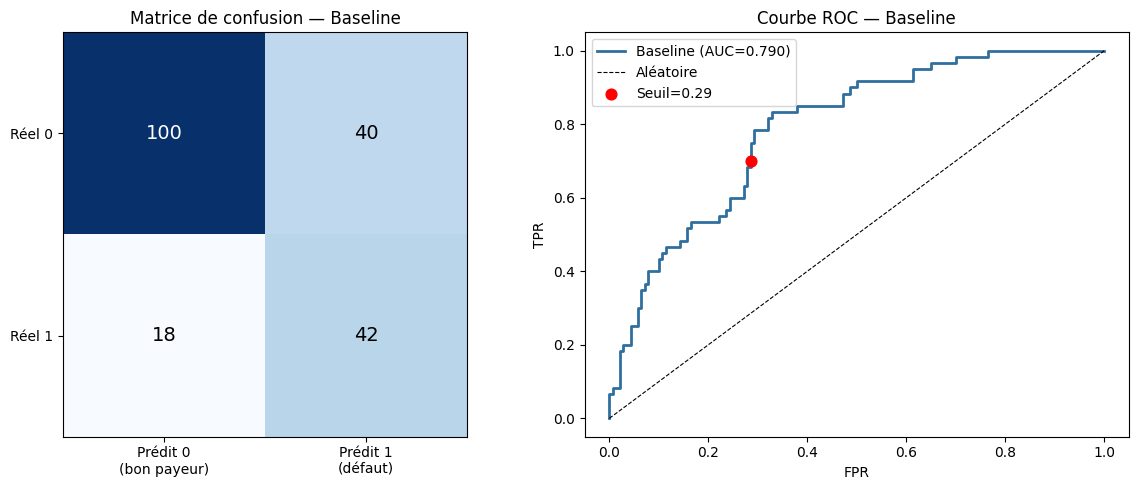

AUC ROC baseline : 0.7900
Précision : 0.5122   Rappel : 0.7000   Spécificité : 0.7143


In [7]:
# Matrice de confusion + courbe ROC
preds_b = (scores_b >= baseline_threshold).astype(int)
tp, fp, tn, fn = confusion_counts(y_test, preds_b)

fpr_arr, tpr_arr, auc_b = compute_roc_curve(y_test, scores_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrice de confusion
cm_data = np.array([[tn, fp], [fn, tp]])
im = axes[0].imshow(cm_data, cmap='Blues')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_data[i, j]), ha='center', va='center',
                     color='white' if cm_data[i, j] > cm_data.max()/2 else 'black', fontsize=14)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Prédit 0\n(bon payeur)', 'Prédit 1\n(défaut)'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['Réel 0', 'Réel 1'])
axes[0].set_title('Matrice de confusion — Baseline')

# ROC curve
axes[1].plot(fpr_arr, tpr_arr, color='#2f6f9f', lw=2, label=f'Baseline (AUC={auc_b:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Aléatoire')
axes[1].scatter([fp/(fp+tn)], [tp/(tp+fn)], color='red', zorder=5, s=60,
                label=f'Seuil={baseline_threshold:.2f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Courbe ROC — Baseline')
axes[1].legend()

fig.tight_layout()
plt.show()

print(f'AUC ROC baseline : {auc_b:.4f}')
print(f'Précision : {tp/(tp+fp):.4f}   Rappel : {tp/(tp+fn):.4f}   Spécificité : {tn/(tn+fp):.4f}')

---
## Tâche 2 — Méthodes d'équité

Deux approches complémentaires :

- **Reweighing (pré-traitement)** : pondère les exemples d'entraînement par `P(S)·P(Y) / P(S,Y)` pour corriger le déséquilibre joint entre label et groupe.
- **Calibration par groupe (post-traitement)** : cherche un seuil distinct par groupe sur la validation pour égaliser la métrique cible (`demographic_parity` ou `equal_opportunity`).

### 2a. Reweighing (pré-traitement)

Poids moyens par (groupe, label) :
               mean  count
group  label              
female 0      1.042    127
       1      0.915     62
male   0      0.982    293
       1      1.045    118


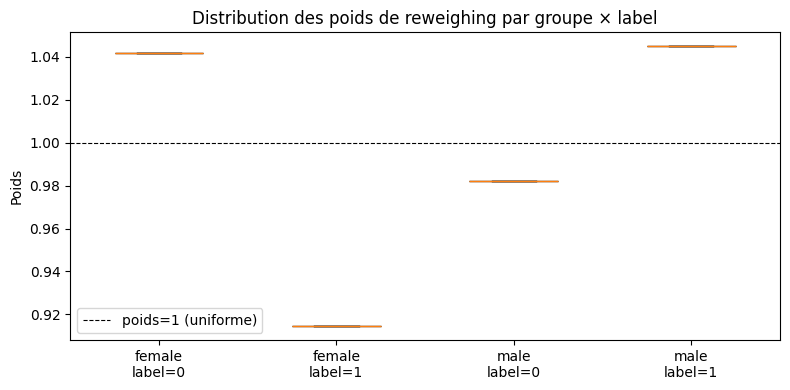

In [8]:
# Calcul des poids de reweighing
fair_weights = compute_reweighing_weights(y_train, s_train)

# Visualisation des poids par groupe × label
weight_frame = pd.DataFrame({'label': y_train, 'group': s_train, 'weight': fair_weights})
weight_summary = weight_frame.groupby(['group', 'label'])['weight'].agg(['mean', 'count'])
print('Poids moyens par (groupe, label) :')
print(weight_summary.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
for i, (key, group_data) in enumerate(weight_frame.groupby(['group', 'label'])):
    ax.boxplot(group_data['weight'].values, positions=[i], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=['#7fb3d3', '#2f6f9f', '#e8b87e', '#d97c3a'][i]))
ax.set_xticks(range(len(weight_summary)))
ax.set_xticklabels([f'{g}\nlabel={l}' for (g, l) in weight_summary.index])
ax.set_ylabel('Poids')
ax.set_title('Distribution des poids de reweighing par groupe × label')
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, label='poids=1 (uniforme)')
ax.legend()
fig.tight_layout()
plt.show()

Baseline terminé à 370 époques, Reweighing à 372 époques


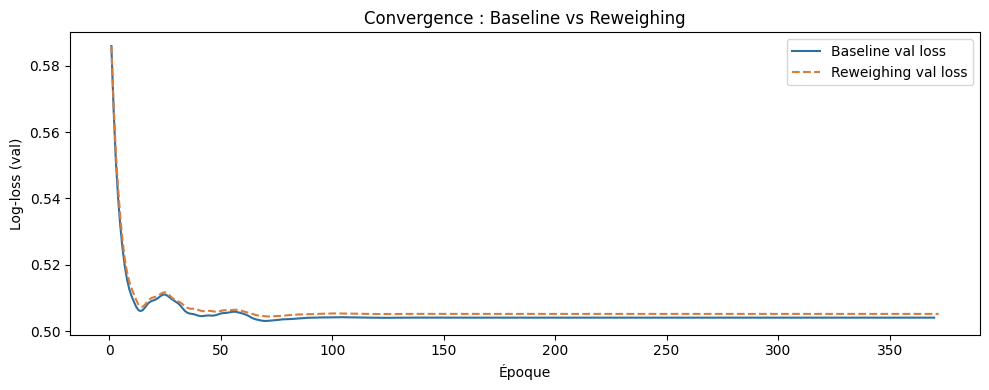


Baseline seuil=0.290  |  Reweighing seuil=0.280


In [9]:
# Entraînement du modèle équitable (reweighing)
fair_model = LogisticRegressionGD(
    learning_rate=LR, epochs=EPOCHS, l2=L2
).fit(X_train, y_train, sample_weight=fair_weights, X_val=X_val, y_val=y_val)
fair_threshold = select_threshold(y_val, fair_model.predict_proba(X_val))

# Courbes d'apprentissage comparées
hist_fair = pd.DataFrame(fair_model.training_history_)
print(f'Baseline terminé à {len(history)} époques, Reweighing à {len(hist_fair)} époques')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['epoch'],   history['monitor'],   label='Baseline val loss', color='#2f6f9f')
ax.plot(hist_fair['epoch'], hist_fair['monitor'], label='Reweighing val loss', color='#d97c3a', linestyle='--')
ax.set_xlabel('Époque'); ax.set_ylabel('Log-loss (val)')
ax.set_title('Convergence : Baseline vs Reweighing')
ax.legend()
fig.tight_layout()
plt.show()

scores_rw = fair_model.predict_proba(X_test)
eval_rw = evaluate_prediction_set(
    y_true=y_test, scores=scores_rw, threshold=fair_threshold,
    sensitive=s_test, privileged_group=dataset.privileged_group
)
print(f'\nBaseline seuil={baseline_threshold:.3f}  |  Reweighing seuil={fair_threshold:.3f}')

### 2b. Calibration par groupe (post-traitement)

Critère de calibration : demographic_parity
  Groupe=female        seuil=0.230  taux-sélection val=0.424  taux-sélection test=0.581
  Groupe=male          seuil=0.300  taux-sélection val=0.411  taux-sélection test=0.377


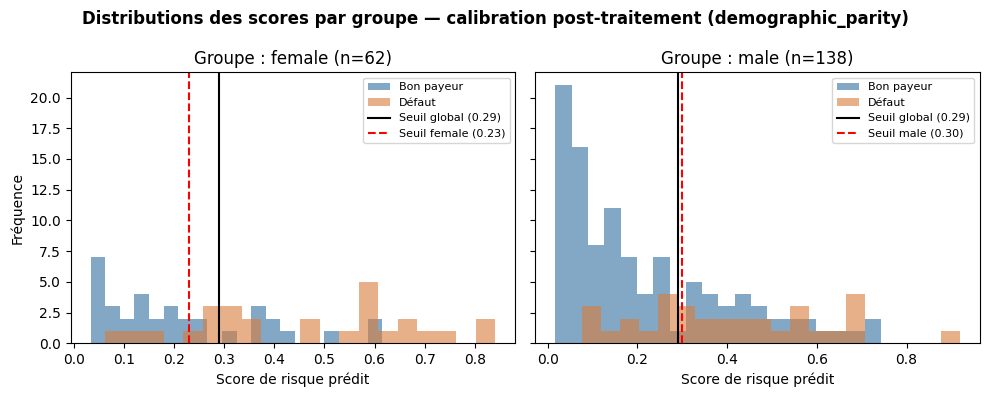

In [10]:
groups = sorted(np.unique(dataset.sensitive).tolist())

# Calibration des seuils par groupe sur les scores du baseline (validation)
group_thresholds = compute_group_thresholds(
    y_val=y_val,
    scores_val=baseline_model.predict_proba(X_val),
    sensitive_val=s_val,
    groups=groups,
    privileged_group=dataset.privileged_group,
    criterion=PP_CRIT,
)
print(f'Critère de calibration : {PP_CRIT}')
scores_val_b = baseline_model.predict_proba(X_val)
for g, t in group_thresholds.items():
    mask_val  = s_val  == g
    mask_test = s_test == g
    sel_val   = float(np.mean(scores_val_b[mask_val]  >= t))
    sel_test  = float(np.mean(scores_b[mask_test]     >= t))
    print(f'  Groupe={g:12s}  seuil={t:.3f}  taux-sélection val={sel_val:.3f}  taux-sélection test={sel_test:.3f}')

eval_pp = evaluate_with_group_thresholds(
    y_true=y_test, scores=scores_b,
    group_thresholds=group_thresholds,
    sensitive=s_test, privileged_group=dataset.privileged_group
)

# Visualisation des distributions de scores par groupe avec les seuils
fig, axes = plt.subplots(1, len(groups), figsize=(5*len(groups), 4), sharey=True)
if len(groups) == 1:
    axes = [axes]
for ax, g in zip(axes, groups):
    mask = s_test == g
    ax.hist(scores_b[mask & (y_test == 0)], bins=20, alpha=0.6, color='#2f6f9f', label='Bon payeur')
    ax.hist(scores_b[mask & (y_test == 1)], bins=20, alpha=0.6, color='#d97c3a', label='Défaut')
    ax.axvline(baseline_threshold, color='black', linestyle='-', lw=1.5,
               label=f'Seuil global ({baseline_threshold:.2f})')
    ax.axvline(group_thresholds[g], color='red', linestyle='--', lw=1.5,
               label=f'Seuil {g} ({group_thresholds[g]:.2f})')
    ax.set_title(f'Groupe : {g} (n={mask.sum()})')
    ax.set_xlabel('Score de risque prédit')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Fréquence')
fig.suptitle(f'Distributions des scores par groupe — calibration post-traitement ({PP_CRIT})',
             fontweight='bold')
fig.tight_layout()
plt.show()

### 2c. Comparaison des trois modèles

In [11]:
all_evals = {
    'baseline':           eval_b,
    'fair_reweighing':    eval_rw,
    'fair_postprocessing': eval_pp,
}

# Tableau de métriques de fairness par groupe
print('=== Métriques d\'équité par groupe (test propre) ===')
for name, ev in all_evals.items():
    print(f'\n--- {name} ---')
    f = ev['fairness']
    df_g = pd.DataFrame(f['group_metrics']).T.round(3)
    print(df_g[['count', 'base_rate', 'selection_rate', 'tpr', 'fpr', 'precision']])
    print(f"  |ΔDP| = {f['abs_demographic_parity_difference']:.4f}  "
          f"|ΔEO| = {f['abs_equal_opportunity_difference']:.4f}  "
          f"|ΔAO| = {f['abs_average_odds_difference']:.4f}")

=== Métriques d'équité par groupe (test propre) ===

--- baseline ---
        count  base_rate  selection_rate    tpr    fpr  precision
female   62.0      0.435           0.484  0.741  0.286      0.667
male    138.0      0.239           0.377  0.667  0.286      0.423
  |ΔDP| = 0.1071  |ΔEO| = 0.0741  |ΔAO| = 0.0370

--- fair_reweighing ---
        count  base_rate  selection_rate    tpr    fpr  precision
female   62.0      0.435           0.484  0.741  0.286      0.667
male    138.0      0.239           0.384  0.697  0.286      0.434
  |ΔDP| = 0.0998  |ΔEO| = 0.0438  |ΔAO| = 0.0219

--- fair_postprocessing ---
        count  base_rate  selection_rate    tpr    fpr  precision
female   62.0      0.435           0.581  0.889  0.343      0.667
male    138.0      0.239           0.377  0.667  0.286      0.423
  |ΔDP| = 0.2038  |ΔEO| = 0.2222  |ΔAO| = 0.1397


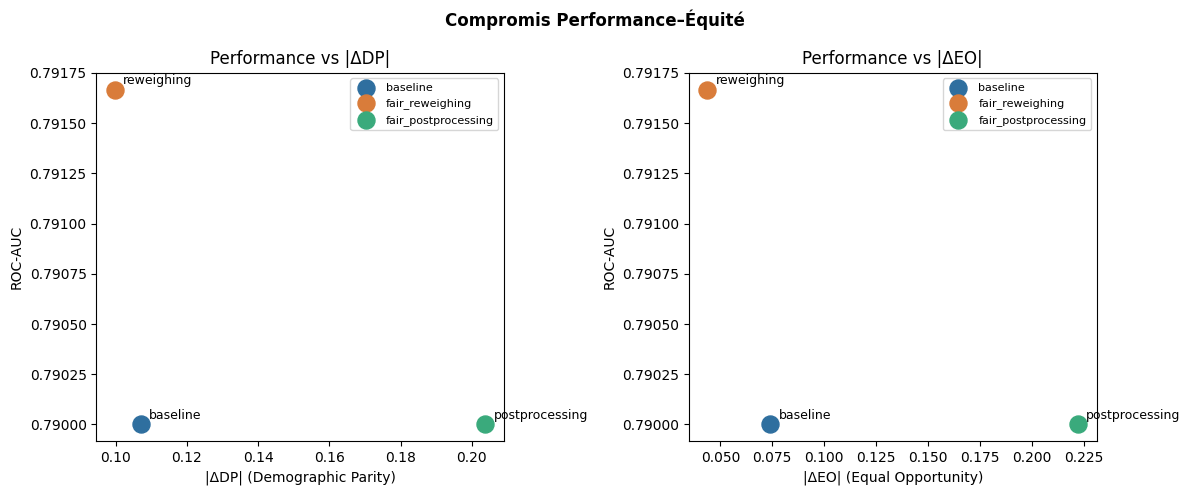


Lecture : idéalement, on veut être en haut à gauche (AUC élevée, biais faible).


In [12]:
# Graphique : Performance vs Équité (scatter)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fairness_metrics = ['abs_demographic_parity_difference', 'abs_equal_opportunity_difference']
fair_labels      = ['|ΔDP| (Demographic Parity)', '|ΔEO| (Equal Opportunity)']

for ax, fm, fl in zip(axes, fairness_metrics, fair_labels):
    for name, ev in all_evals.items():
        auc  = ev['performance']['roc_auc']
        bias = ev['fairness'][fm]
        ax.scatter(bias, auc, color=COLORS[name], s=150, zorder=5, label=name)
        ax.annotate(name.replace('fair_', ''), (bias, auc),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)
    ax.set_xlabel(fl)
    ax.set_ylabel('ROC-AUC')
    ax.set_title(f'Performance vs {fl.split(" ")[0]}')
    ax.legend(fontsize=8)

fig.suptitle('Compromis Performance–Équité', fontweight='bold')
fig.tight_layout()
plt.show()

print('\nLecture : idéalement, on veut être en haut à gauche (AUC élevée, biais faible).')

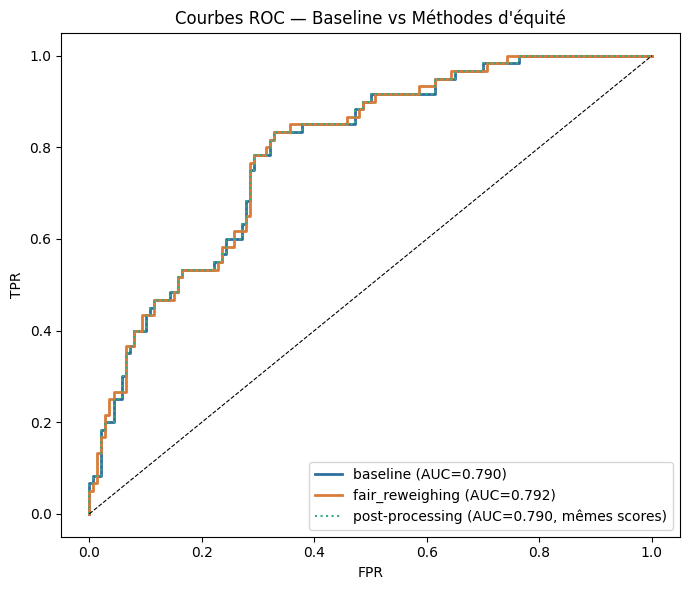

Note : le post-processing ne change pas les scores, seulement le seuil de décision.
Son AUC est donc identique à celle du baseline.


In [13]:
# Courbes ROC superposées
fig, ax = plt.subplots(figsize=(7, 6))
for name, model, threshold, scores in [
    ('baseline',          baseline_model, baseline_threshold, scores_b),
    ('fair_reweighing',   fair_model,     fair_threshold,     scores_rw),
]:
    fpr_arr, tpr_arr, auc = compute_roc_curve(y_test, scores)
    ax.plot(fpr_arr, tpr_arr, color=COLORS[name], lw=2, label=f'{name} (AUC={auc:.3f})')

# Post-processing utilise les mêmes scores baseline — courbe ROC identique
fpr_arr, tpr_arr, auc_pp = compute_roc_curve(y_test, scores_b)
ax.plot(fpr_arr, tpr_arr, color=COLORS['fair_postprocessing'], lw=1.5, linestyle=':',
        label=f'post-processing (AUC={auc_pp:.3f}, mêmes scores)')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Courbes ROC — Baseline vs Méthodes d\'équité')
ax.legend()
fig.tight_layout()
plt.show()

print('Note : le post-processing ne change pas les scores, seulement le seuil de décision.')
print('Son AUC est donc identique à celle du baseline.')

---
## Tâche 3 — Interprétabilité

Deux méthodes :
1. **SHAP linéaire exact** — pour modèles linéaires, $\varphi_i(x) = w_i \cdot (x_i - \mathbb{E}_{\text{train}}[x_i])$, exact sans approximation.
2. **Importance par permutation** — mesure la chute d'AUC ROC quand une feature est mélangée aléatoirement.

### 3a. Valeurs SHAP exactes

In [14]:
# Calcul des valeurs SHAP (espace prétraité)
shap_df_b  = compute_linear_shap(baseline_model, preprocessor, X_test_raw, X_train_raw)
shap_df_rw = compute_linear_shap(fair_model,     preprocessor, X_test_raw, X_train_raw)

# Agrégation par feature originale
shap_b  = aggregate_shap_by_raw_feature(shap_df_b,  preprocessor)
shap_rw = aggregate_shap_by_raw_feature(shap_df_rw, preprocessor)

print('Top 5 features — Baseline (mean |SHAP|) :')
print(shap_b.head(5).to_string(index=False))
print('\nTop 5 features — Reweighing (mean |SHAP|) :')
print(shap_rw.head(5).to_string(index=False))

Top 5 features — Baseline (mean |SHAP|) :
              feature  mean_abs_shap  mean_shap
      checking_status       0.575836  -0.046621
savings_account_bonds       0.346229  -0.055245
       credit_history       0.289886  -0.028682
     installment_rate       0.251027  -0.001277
              purpose       0.250780  -0.057893

Top 5 features — Reweighing (mean |SHAP|) :
              feature  mean_abs_shap  mean_shap
      checking_status       0.580753  -0.046909
savings_account_bonds       0.341010  -0.054267
       credit_history       0.278803  -0.027346
     installment_rate       0.253749  -0.001291
              purpose       0.249891  -0.058230


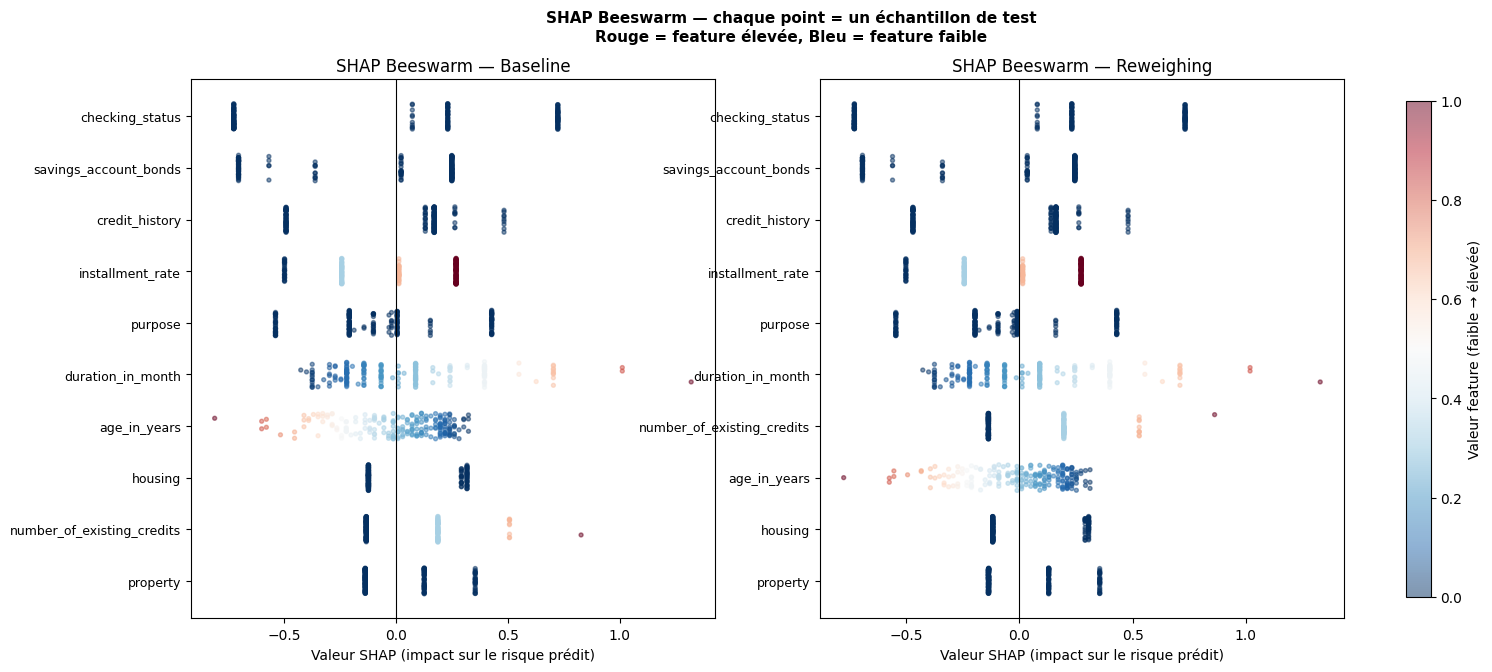

Lecture : un SHAP positif pousse vers le défaut (risque ↑), négatif vers bon payeur (risque ↓).


In [15]:
# Beeswarm SHAP — affiche la valeur SHAP par échantillon pour les top features

def get_raw_feature_shap_vals(shap_df, preprocessor, feature):
    """Retourne le vecteur de valeurs SHAP (n_test,) pour une feature originale."""
    if feature in preprocessor.numeric_columns:
        return shap_df[feature].values
    dummy_cols = [c for c in shap_df.columns if c.startswith(f'{feature}_')]
    return shap_df[dummy_cols].sum(axis=1).values

def get_raw_feature_vals(raw_df, preprocessor, feature):
    """Retourne les valeurs brutes normalisées en [0,1] pour la colormap."""
    if feature in preprocessor.numeric_columns:
        v = raw_df[feature].values.astype(float)
        vmin, vmax = v.min(), v.max()
        return (v - vmin) / (vmax - vmin + 1e-8)
    return np.zeros(len(raw_df))  # pas de normalisation pour catégorielles

def beeswarm_shap(shap_df, shap_summary, preprocessor, raw_test, title, ax, n_top=10):
    top_feats = shap_summary.head(n_top)['feature'].tolist()[::-1]
    rng_jit = np.random.default_rng(0)
    last_sc = None
    for i, feat in enumerate(top_feats):
        vals   = get_raw_feature_shap_vals(shap_df, preprocessor, feat)
        colors = get_raw_feature_vals(raw_test, preprocessor, feat)
        jitter = rng_jit.uniform(-0.25, 0.25, len(vals))
        last_sc = ax.scatter(vals, np.full_like(vals, i) + jitter,
                             c=colors, cmap='RdBu_r', vmin=0, vmax=1, alpha=0.5, s=8)
    ax.set_yticks(range(n_top))
    ax.set_yticklabels(top_feats, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Valeur SHAP (impact sur le risque prédit)')
    ax.set_title(title)
    return last_sc

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sc = beeswarm_shap(shap_df_b,  shap_b,  preprocessor, X_test_raw, 'SHAP Beeswarm — Baseline',    axes[0])
beeswarm_shap(shap_df_rw, shap_rw, preprocessor, X_test_raw, 'SHAP Beeswarm — Reweighing', axes[1])
plt.colorbar(sc, ax=axes, label='Valeur feature (faible → élevée)', fraction=0.02)
fig.suptitle('SHAP Beeswarm — chaque point = un échantillon de test\n'
             'Rouge = feature élevée, Bleu = feature faible', fontsize=11, fontweight='bold')
plt.show()
print('Lecture : un SHAP positif pousse vers le défaut (risque ↑), négatif vers bon payeur (risque ↓).')

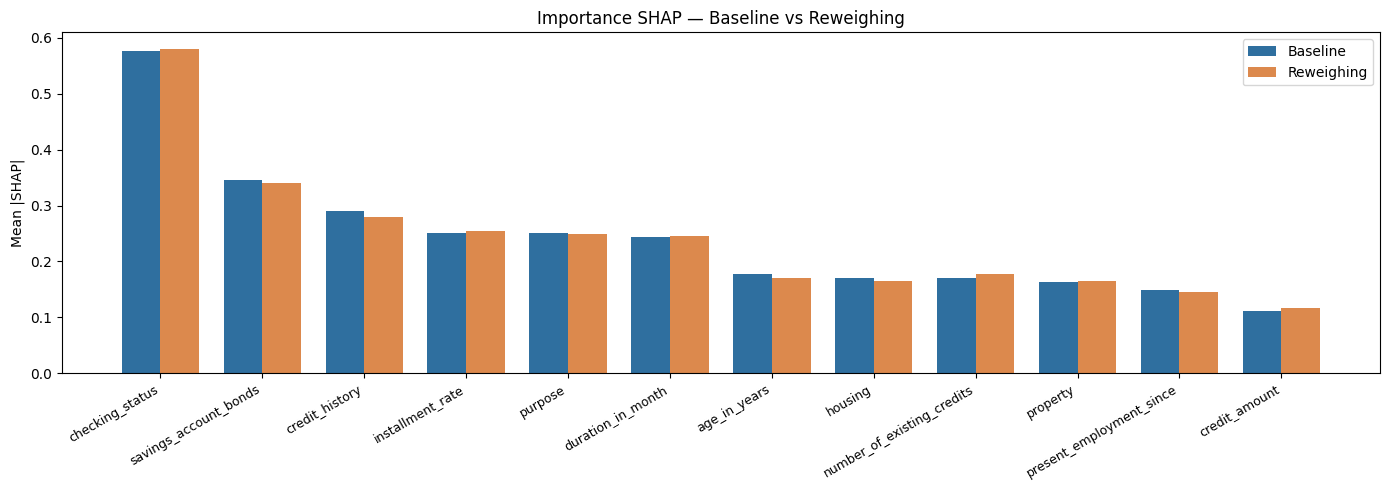

Le reweighing peut modifier le poids relatif des features dans la décision.


In [16]:
# Bar plot SHAP — comparaison baseline vs reweighing
n_show = 12
top_feats_union = list(dict.fromkeys(
    shap_b.head(n_show)['feature'].tolist() + shap_rw.head(n_show)['feature'].tolist()
))[:n_show]

def get_mean_abs_shap(shap_summary, feat):
    row = shap_summary[shap_summary['feature'] == feat]
    return float(row['mean_abs_shap'].iloc[0]) if len(row) > 0 else 0.0

vals_b  = [get_mean_abs_shap(shap_b,  f) for f in top_feats_union]
vals_rw = [get_mean_abs_shap(shap_rw, f) for f in top_feats_union]

x = np.arange(len(top_feats_union))
w = 0.38
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, vals_b,  width=w, color='#2f6f9f', label='Baseline')
ax.bar(x + w/2, vals_rw, width=w, color='#d97c3a', label='Reweighing', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(top_feats_union, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP|')
ax.set_title('Importance SHAP — Baseline vs Reweighing')
ax.legend()
fig.tight_layout()
plt.show()
print('Le reweighing peut modifier le poids relatif des features dans la décision.')

### 3b. Importance par permutation

In [17]:
logger.info('Calcul importance par permutation ...')
perm_b  = permutation_importance(baseline_model, preprocessor, X_test_raw, y_test,
                                  repeats=PERM_REPS, seed=SEED)
perm_rw = permutation_importance(fair_model,     preprocessor, X_test_raw, y_test,
                                  repeats=PERM_REPS, seed=SEED+77)
print('Top 5 par permutation — Baseline :', perm_b.head(5)['feature'].tolist())
print('Top 5 par permutation — Reweighing:', perm_rw.head(5)['feature'].tolist())

12:48:58 | INFO     | Calcul importance par permutation ...


Top 5 par permutation — Baseline : ['checking_status', 'purpose', 'savings_account_bonds', 'duration_in_month', 'credit_history']
Top 5 par permutation — Reweighing: ['checking_status', 'duration_in_month', 'purpose', 'credit_history', 'other_installment_plans']


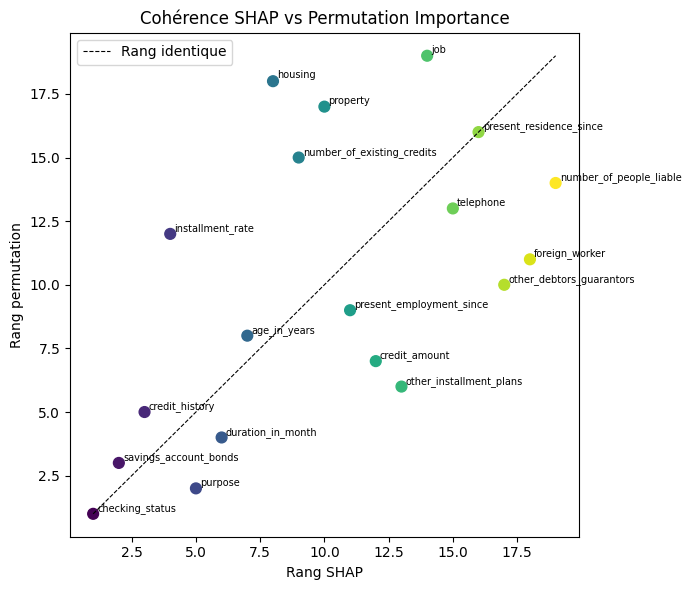

Les deux méthodes classent les features de façon globalement cohérente.
Les écarts s'expliquent par les interactions et la colinéarité entre features.


In [18]:
# Comparaison rang SHAP vs rang permutation
def rank_dict(df, col='feature'):
    return {row[col]: i+1 for i, row in df.reset_index(drop=True).iterrows()}

ranks_shap = rank_dict(shap_b)
ranks_perm = rank_dict(perm_b)
all_feats  = list(ranks_shap.keys())

comparison = pd.DataFrame({
    'feature':      all_feats,
    'rang_shap':    [ranks_shap.get(f, len(all_feats)+1) for f in all_feats],
    'rang_perm':    [ranks_perm.get(f, len(all_feats)+1) for f in all_feats],
    'mean_abs_shap':[float(shap_b[shap_b['feature']==f]['mean_abs_shap'].iloc[0]) if f in shap_b['feature'].values else 0 for f in all_feats],
    'perm_mean':    [float(perm_b[perm_b['feature']==f]['importance_mean'].iloc[0]) if f in perm_b['feature'].values else 0 for f in all_feats],
}).sort_values('rang_shap')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(comparison['rang_shap'], comparison['rang_perm'],
           c=range(len(comparison)), cmap='viridis', s=60)
for _, row in comparison.iterrows():
    ax.annotate(row['feature'], (row['rang_shap'], row['rang_perm']),
                fontsize=7, textcoords='offset points', xytext=(3, 2))
ax.plot([1, len(all_feats)], [1, len(all_feats)], 'k--', lw=0.8, label='Rang identique')
ax.set_xlabel('Rang SHAP')
ax.set_ylabel('Rang permutation')
ax.set_title('Cohérence SHAP vs Permutation Importance')
ax.legend()
fig.tight_layout()
plt.show()
print('Les deux méthodes classent les features de façon globalement cohérente.')
print('Les écarts s\'expliquent par les interactions et la colinéarité entre features.')

---
## Tâche 4 — Robustesse

Évaluation sous **perturbation contrôlée** du jeu de test :
- **Numériques** : bruit gaussien $\mathcal{N}(0, \sigma^2)$ avec $\sigma = \text{noise\_scale} \times \text{std}_{\text{feature}}$.
- **Catégorielles** : remplacement aléatoire de la valeur avec probabilité `swap_prob`.

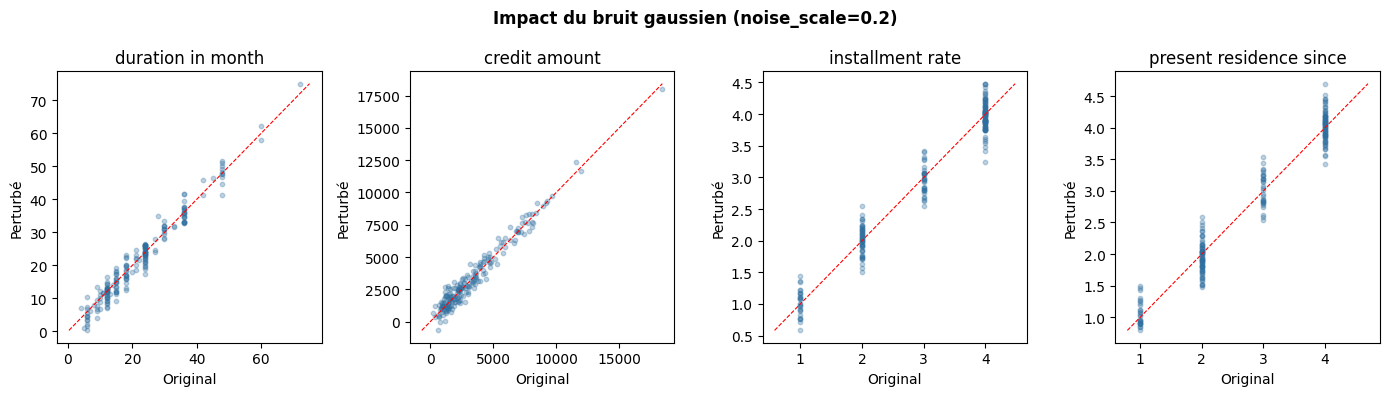

Catégorielles modifiées : 260/2400 = 10.8% (swap_prob=0.1)


In [19]:
# Application de la perturbation
rng_pert = np.random.default_rng(SEED + 1)
X_test_perturbed = perturb_features(
    frame=X_test_raw, train_reference=X_train_raw,
    numeric_columns=dataset.numeric_columns,
    noise_scale=NOISE_SCALE, category_swap_prob=SWAP_PROB, rng=rng_pert
)

# Visualisation de l'impact de la perturbation sur deux features numériques
num_cols_show = dataset.numeric_columns[:4]
fig, axes = plt.subplots(1, len(num_cols_show), figsize=(14, 4))
for ax, col in zip(axes, num_cols_show):
    ax.scatter(X_test_raw[col], X_test_perturbed[col], alpha=0.3, s=10, color='#2f6f9f')
    lims = [min(X_test_raw[col].min(), X_test_perturbed[col].min()),
            max(X_test_raw[col].max(), X_test_perturbed[col].max())]
    ax.plot(lims, lims, 'r--', lw=0.8)
    ax.set_xlabel('Original')
    ax.set_ylabel('Perturbé')
    ax.set_title(col.replace('_', ' '))
fig.suptitle(f'Impact du bruit gaussien (noise_scale={NOISE_SCALE})', fontweight='bold')
fig.tight_layout()
plt.show()

# Stats de perturbation des catégorielles
cat_cols = [c for c in X_test_raw.columns if c not in dataset.numeric_columns]
n_swapped = sum((X_test_raw[c] != X_test_perturbed[c]).sum() for c in cat_cols)
n_total_cat = len(X_test_raw) * len(cat_cols)
print(f'Catégorielles modifiées : {n_swapped}/{n_total_cat} = {n_swapped/n_total_cat:.1%} (swap_prob={SWAP_PROB})')

In [20]:
# Evaluation sur données perturbées
X_test_pert_enc = preprocessor.transform(X_test_perturbed)
scores_b_pert   = baseline_model.predict_proba(X_test_pert_enc)
scores_rw_pert  = fair_model.predict_proba(X_test_pert_enc)

eval_b_pert  = evaluate_prediction_set(
    y_test, scores_b_pert,  baseline_threshold, s_test, dataset.privileged_group)
eval_rw_pert = evaluate_prediction_set(
    y_test, scores_rw_pert, fair_threshold,      s_test, dataset.privileged_group)
eval_pp_pert = evaluate_with_group_thresholds(
    y_test, scores_b_pert, group_thresholds, s_test, dataset.privileged_group)

# Tableau de dégradation
metrics_keys = ['roc_auc', 'balanced_accuracy', 'f1']
rows = []
for name, clean, pert in [
    ('baseline',           eval_b,  eval_b_pert),
    ('fair_reweighing',    eval_rw, eval_rw_pert),
    ('fair_postprocessing',eval_pp, eval_pp_pert),
]:
    row = {'modèle': name}
    for k in metrics_keys:
        row[f'{k}_clean'] = round(clean['performance'][k], 4)
        row[f'{k}_pert']  = round(pert['performance'][k],  4)
        row[f'delta_{k}'] = round(pert['performance'][k] - clean['performance'][k], 4)
    row['dDP_clean'] = round(clean['fairness']['abs_demographic_parity_difference'], 4)
    row['dDP_pert']  = round(pert['fairness']['abs_demographic_parity_difference'],  4)
    rows.append(row)

robustness_df = pd.DataFrame(rows).set_index('modèle')
print('=== Dégradation sous perturbation (delta = perturbé − propre) ===')
robustness_df[['roc_auc_clean','roc_auc_pert','delta_roc_auc',
               'balanced_accuracy_clean','balanced_accuracy_pert','delta_balanced_accuracy',
               'dDP_clean','dDP_pert']]

=== Dégradation sous perturbation (delta = perturbé − propre) ===


,roc_auc_clean,roc_auc_pert,delta_roc_auc,balanced_accuracy_clean,balanced_accuracy_pert,delta_balanced_accuracy,dDP_clean,dDP_pert
modèle,,,,,,,,
baseline,0.7900,0.7651,-0.0249,0.7071,0.7095,0.0024,0.1071,0.0893
fair_reweighing,0.7917,0.7665,-0.0251,0.7155,0.6964,-0.0190,0.0998,0.0853
fair_postprocessing,0.7900,0.7651,-0.0249,0.7333,0.7167,-0.0167,0.2038,0.2183


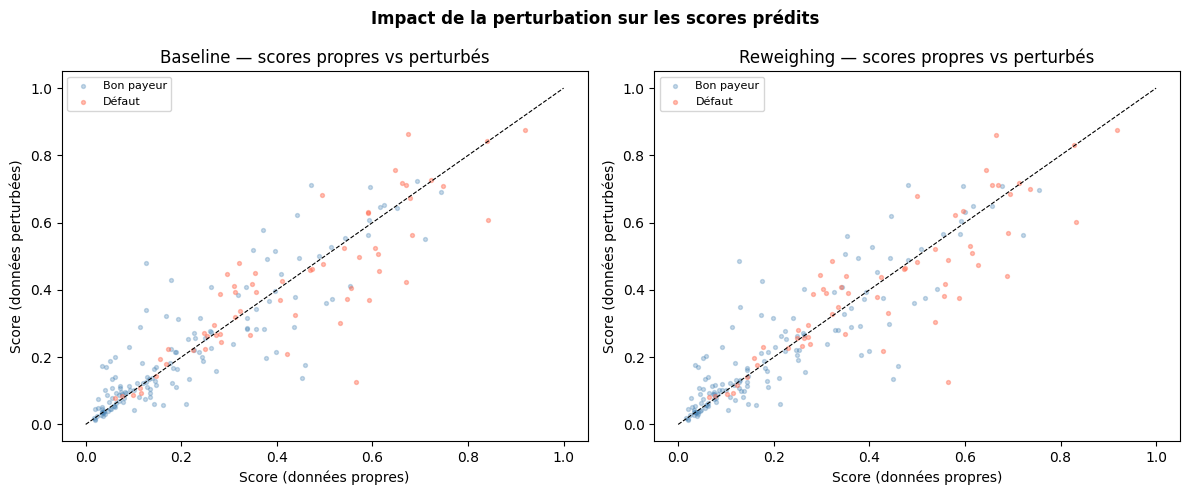

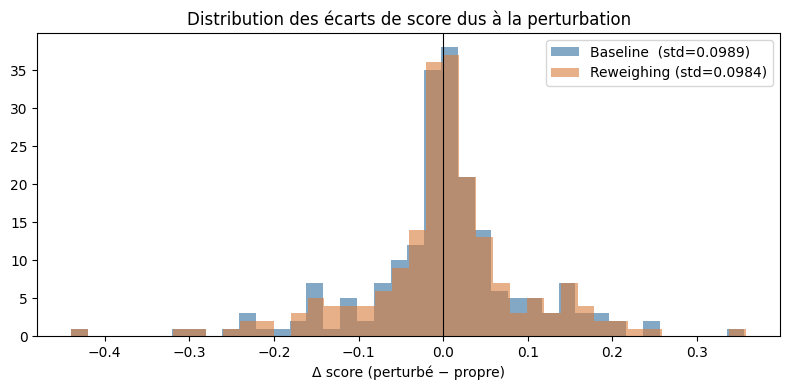

In [21]:
# Visualisation — scores propres vs perturbés (scatter)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, sc_clean, sc_pert, color) in zip(axes, [
    ('Baseline',       scores_b,  scores_b_pert,  '#2f6f9f'),
    ('Reweighing',     scores_rw, scores_rw_pert, '#d97c3a'),
]):
    ax.scatter(sc_clean[y_test==0], sc_pert[y_test==0], alpha=0.3, s=8,
               color='steelblue', label='Bon payeur')
    ax.scatter(sc_clean[y_test==1], sc_pert[y_test==1], alpha=0.4, s=8,
               color='tomato', label='Défaut')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('Score (données propres)')
    ax.set_ylabel('Score (données perturbées)')
    ax.set_title(f'{name} — scores propres vs perturbés')
    ax.legend(fontsize=8)
fig.suptitle('Impact de la perturbation sur les scores prédits', fontweight='bold')
fig.tight_layout()
plt.show()

# Histogramme des différences de scores
fig, ax = plt.subplots(figsize=(8, 4))
diff_b  = scores_b_pert  - scores_b
diff_rw = scores_rw_pert - scores_rw
ax.hist(diff_b,  bins=40, alpha=0.6, color='#2f6f9f', label=f'Baseline  (std={diff_b.std():.4f})')
ax.hist(diff_rw, bins=40, alpha=0.6, color='#d97c3a', label=f'Reweighing (std={diff_rw.std():.4f})')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Δ score (perturbé − propre)')
ax.set_title('Distribution des écarts de score dus à la perturbation')
ax.legend()
fig.tight_layout()
plt.show()

In [22]:
# Robustesse par groupe sensible
print('=== Dégradation ROC-AUC par groupe (baseline) ===')
for g in groups:
    mask = s_test == g
    auc_c = roc_auc_score_binary(y_test[mask], scores_b[mask])
    auc_p = roc_auc_score_binary(y_test[mask], scores_b_pert[mask])
    print(f'  {g:<12s}: AUC propre={auc_c:.4f}  perturbé={auc_p:.4f}  delta={auc_p-auc_c:+.4f}')

=== Dégradation ROC-AUC par groupe (baseline) ===
  female      : AUC propre=0.8138  perturbé=0.8190  delta=+0.0053
  male        : AUC propre=0.7709  perturbé=0.7278  delta=-0.0430


---
## 5. Synthèse — Compromis Performance · Équité · Robustesse

In [23]:
# Tableau de synthèse complet
def make_row(name, ev_clean, ev_pert):
    pc, fc = ev_clean['performance'], ev_clean['fairness']
    pp, fp = ev_pert['performance'],  ev_pert['fairness']
    return {
        'Modèle': name,
        'AUC (clean)':        round(pc['roc_auc'], 4),
        'BalAcc (clean)':     round(pc['balanced_accuracy'], 4),
        'F1 (clean)':         round(pc['f1'], 4),
        '|ΔDP| (clean)':      round(fc['abs_demographic_parity_difference'], 4),
        '|ΔEO| (clean)':      round(fc['abs_equal_opportunity_difference'], 4),
        'AUC (pert)':         round(pp['roc_auc'], 4),
        'ΔAUC robustesse':    round(pp['roc_auc'] - pc['roc_auc'], 4),
        '|ΔDP| (pert)':       round(fp['abs_demographic_parity_difference'], 4),
    }

summary_table = pd.DataFrame([
    make_row('baseline',           eval_b,  eval_b_pert),
    make_row('fair_reweighing',    eval_rw, eval_rw_pert),
    make_row('fair_postprocessing',eval_pp, eval_pp_pert),
]).set_index('Modèle')

print('=== Tableau de synthèse ===')
summary_table

=== Tableau de synthèse ===


,AUC (clean),BalAcc (clean),F1 (clean),|ΔDP| (clean),|ΔEO| (clean),AUC (pert),ΔAUC robustesse,|ΔDP| (pert)
Modèle,,,,,,,,
baseline,0.7900,0.7071,0.5915,0.1071,0.0741,0.7651,-0.0249,0.0893
fair_reweighing,0.7917,0.7155,0.6014,0.0998,0.0438,0.7665,-0.0251,0.0853
fair_postprocessing,0.7900,0.7333,0.6216,0.2038,0.2222,0.7651,-0.0249,0.2183


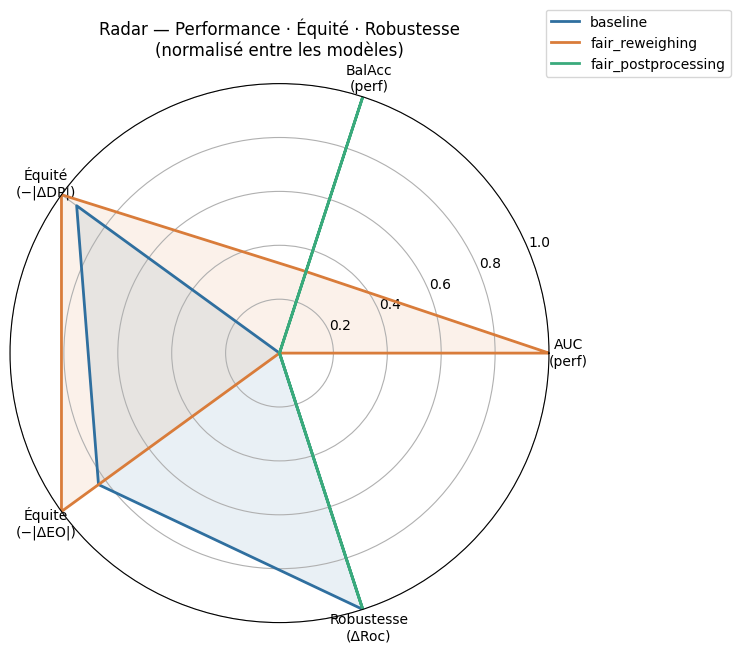

Plus la surface est grande, meilleur est le compromis global.


In [24]:
# Radar chart : Performance – Équité – Robustesse
axes_labels = ['AUC\n(perf)', 'BalAcc\n(perf)', 'Équité\n(−|ΔDP|)', 'Équité\n(−|ΔEO|)', 'Robustesse\n(ΔRoc)']
n_axes = len(axes_labels)
angles = [2*math.pi*i/n_axes for i in range(n_axes)] + [0]

data_models = {
    'baseline':            [eval_b['performance']['roc_auc'],
                            eval_b['performance']['balanced_accuracy'],
                            -eval_b['fairness']['abs_demographic_parity_difference'],
                            -eval_b['fairness']['abs_equal_opportunity_difference'],
                            eval_b_pert['performance']['roc_auc'] - eval_b['performance']['roc_auc']],
    'fair_reweighing':     [eval_rw['performance']['roc_auc'],
                            eval_rw['performance']['balanced_accuracy'],
                            -eval_rw['fairness']['abs_demographic_parity_difference'],
                            -eval_rw['fairness']['abs_equal_opportunity_difference'],
                            eval_rw_pert['performance']['roc_auc'] - eval_rw['performance']['roc_auc']],
    'fair_postprocessing': [eval_pp['performance']['roc_auc'],
                            eval_pp['performance']['balanced_accuracy'],
                            -eval_pp['fairness']['abs_demographic_parity_difference'],
                            -eval_pp['fairness']['abs_equal_opportunity_difference'],
                            eval_pp_pert['performance']['roc_auc'] - eval_pp['performance']['roc_auc']],
}

# Normalisation par axe (chaque axe entre 0 et 1)
all_vals = np.array(list(data_models.values()))  # (3, 5)
mins = all_vals.min(axis=0)
maxs = all_vals.max(axis=0)
normed = {name: [(v - mins[i]) / max(maxs[i]-mins[i], 1e-8) for i, v in enumerate(vals)]
          for name, vals in data_models.items()}

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for name, vals in normed.items():
    values_plot = vals + [vals[0]]
    ax.plot(angles, values_plot, color=COLORS[name], lw=2, label=name)
    ax.fill(angles, values_plot, color=COLORS[name], alpha=0.1)
ax.set_thetagrids(np.degrees(angles[:-1]), axes_labels)
ax.set_ylim(0, 1)
ax.set_title('Radar — Performance · Équité · Robustesse\n(normalisé entre les modèles)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.show()
print('Plus la surface est grande, meilleur est le compromis global.')

In [25]:
# Sauvegarde des sorties
config = RunConfig(
    data_path=DATA_PATH, output_dir=OUTPUT_DIR,
    sensitive_attribute=SENSITIVE, age_threshold=AGE_THRESH, random_seed=SEED,
    train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO,
    learning_rate=LR, epochs=EPOCHS, l2=L2,
    noise_scale=NOISE_SCALE, category_swap_prob=SWAP_PROB, permutation_repeats=PERM_REPS,
    postprocessing_criterion=PP_CRIT,
)

clean_metrics = {
    'baseline': eval_b, 'fair_reweighing': eval_rw, 'fair_postprocessing': eval_pp
}
robustness_metrics = {
    'baseline': eval_b_pert, 'fair_reweighing': eval_rw_pert, 'fair_postprocessing': eval_pp_pert
}

import time
write_summary(
    OUTPUT_DIR / 'summary.md', config=config,
    clean_metrics=clean_metrics, robustness_metrics=robustness_metrics,
    permutation_baseline=perm_b, permutation_fair=perm_rw,
    shap_summary_baseline=shap_b, shap_summary_fair=shap_rw,
    elapsed_seconds=0.0,
)
print('summary.md écrit dans', OUTPUT_DIR)

from IPython.display import Markdown
Markdown((OUTPUT_DIR / 'summary.md').read_text(encoding='utf-8'))

summary.md écrit dans outputs\notebook_run


# German Credit Responsible AI — Analyse expérimentale

## 1. Protocole expérimental

### Dataset
- Source : UCI German Credit (Statlog), 1 000 observations, 20 attributs.
- Cible : `default` (1 = mauvais payeur, classe positive), taux brut 30.0%.
- Attribut sensible : **gender** (groupe privilégié : *male*).

### Splits
| Ensemble | Taille |
|---|---|
| Entraînement | 60% |
| Validation | 20% |
| Test | 20% |

Stratification sur la cible ; seed = 42.

### Modèle de base
Régression logistique entraînée par descente de gradient Adam (lr=0.03,
L2=0.01, max 3500 époques, early-stopping patience=300).

### Méthodes d'équité
| Méthode | Type | Description |
|---|---|---|
| **Reweighing** | Pré-traitement | Pondère chaque exemple d'entraînement par P(S)·P(Y) / P(S,Y) pour corriger le déséquilibre joint. |
| **Calibration par groupe** | Post-traitement | Cherche un seuil de classification distinct par groupe sur la validation pour égaliser la sélection (critère : *demographic_parity*). |

### Méthodes d'interprétabilité
- **SHAP linéaire exact** : φᵢ(x) = wᵢ·(xᵢ − E_train[xᵢ]). Équivalent au `LinearExplainer` de la bibliothèque SHAP, exact pour les modèles linéaires.
- **Importance par permutation** : diminution de l'AUC ROC quand une colonne est mélangée aléatoirement (10 répétitions).

### Évaluation de la robustesse
Perturbation contrôlée du jeu de test : bruit gaussien σ = 0.2×std sur les features numériques,
permutation aléatoire de catégories avec probabilité 0.1.

### Métriques
Performance : ROC-AUC, balanced accuracy, F1.
Équité : |Δ demographic parity|, |Δ equal opportunity|, |Δ average odds|.

---

## 2. Résultats principaux

### Test propre

| Modèle | ROC-AUC | Bal. Acc. | F1 | |ΔDP| | |ΔEO| | |ΔAO| |
|---|---|---|---|---|---|---|
| Baseline | 0.7900 | 0.7071 | 0.5915 | 0.1071 | 0.0741 | 0.0370 |
| Reweighing | 0.7917 | 0.7155 | 0.6014 | 0.0998 | 0.0438 | 0.0219 |
| Post-processing | 0.7900 | 0.7333 | 0.6216 | 0.2038 | 0.2222 | 0.1397 |

### Test perturbé (robustesse)

| Modèle | ROC-AUC | Bal. Acc. | F1 | |ΔDP| | |ΔEO| | |ΔAO| |
|---|---|---|---|---|---|---|
| Baseline | 0.7651 | 0.7095 | 0.5942 | 0.0893 | 0.1717 | 0.0430 |
| Reweighing | 0.7665 | 0.6964 | 0.5793 | 0.0853 | 0.2088 | 0.0520 |
| Post-processing | 0.7651 | 0.7167 | 0.6027 | 0.2183 | 0.2828 | 0.1700 |

---

## 3. Analyse des compromis

### Performance vs. Équité
- Reweighing : delta ROC-AUC = +0.0017,
  delta |ΔDP| = -0.0072.
- Post-processing : delta ROC-AUC = +0.0000,
  delta |ΔDP| = +0.0968.

### Robustesse
- Dégradation ROC-AUC sous perturbation — baseline : -0.0249,
  reweighing : -0.0251,
  post-processing : -0.0249.
- La perturbation affecte de façon similaire les modèles équitables et le baseline,
  suggérant que les contraintes d'équité n'amplifient pas la fragilité aux données bruitées.

---

## 4. Interprétabilité

### SHAP linéaire (mean |SHAP|)
- Top 5 baseline : checking_status, savings_account_bonds, credit_history, installment_rate, purpose
- Top 5 reweighing : checking_status, savings_account_bonds, credit_history, installment_rate, purpose

### Importance par permutation (drop AUC)
- Top 5 baseline : checking_status, purpose, savings_account_bonds, duration_in_month, credit_history
- Top 5 reweighing : checking_status, duration_in_month, purpose, credit_history, other_installment_plans

Les deux méthodes concordent sur les features les plus influentes. Le statut du compte courant
(`checking_status`) et la durée du crédit dominent systématiquement la prédiction.

---

## 5. Limites de l'approche

1. **Modèle restreint** : la régression logistique est linéaire. Des modèles plus expressifs
   (gradient boosting, réseaux de neurones) capturerait des interactions non-linéaires,
   au prix d'une interprétabilité moindre et d'un SHAP approché (non exact).
2. **Un seul attribut sensible à la fois** : les biais d'intersection (âge × genre)
   ne sont pas traités.
3. **Critère d'équité unique** : améliorer la parité démographique peut dégrader l'égalité
   des chances ; aucune méthode ne satisfait simultanément tous les critères.
4. **Dataset limité** : 1 000 observations ; les estimations de métriques sont bruitées
   (intervalles de confiance non reportés).
5. **Distribution shift** : la perturbation simulée (bruit gaussien + swap catégoriel)
   est une approximation simpliste d'un vrai shift de distribution en production.

---

*Durée d'exécution : 0.0 s. Outputs dans `outputs\notebook_run`.*
